<a href="https://colab.research.google.com/github/mana-1538/AI_ML-practice-projects/blob/main/MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# download_data.py
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

train_set = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")
print(f"Image shape: {train_set[0][0].shape}")  # Should be torch.Size([1, 28, 28])

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.90MB/s]


Train samples: 60000, Test samples: 10000
Image shape: torch.Size([1, 28, 28])


In [6]:
from torch import relu
# model.py
import torch
import torch.nn as nn


class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 =nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding = 1) # as for grayscale image,in_channel =1
        self.conv2 =nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding = 1) #first layer out_channels become 2nd layers in_channels
        self.maxpool=nn.MaxPool2d(kernel_size=2,stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(in_features=6272,out_features=128) # in_features = 32*14*14 = (out_channels from last conv layer * output dimension after pooling)
        self.fc2 = nn.Linear(in_features = 128,out_features = 10)
        pass

    def forward(self, x):
        # x: (B, 1, 28, 28)
        x = self.conv1(x)
        x=self.relu(x)
        x=self.relu(self.conv2(x))
        x = self.maxpool(x)
        # flattening the tensor
        x= torch.flatten(x,1)
        x=self.relu(self.fc1(x))
        x=self.fc2(x)

        return x
# sanity check
model = MyCNN()
print(f"Total parameters : {sum(p.numel() for p in model.parameters())}")


Total parameters : 809034


In [8]:
# train.py  — fill in the TODOs
import torch
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
epochs = 10
train_losses = []
val_accuracy = []
def train(model, train_loader, val_loader, epochs, lr):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for images, labels in train_loader:
            # zero_grad → forward → loss → backward → step
            optimizer.zero_grad()  # must
            outputs = model(images)
            loss = criterion(outputs , labels)
            loss.backward()
            optimizer.step()
            total_loss +=loss.item()
            pass

        avg_loss = total_loss /len(train_loader)
        train_losses.append(avg_loss)
        # validation loop
        model.eval()
        val_acc = 0.0

        with torch.no_grad():
          for images,labels in val_loader:
            outputs = model(images)
            batch_acc = (outputs.argmax(dim=1)==labels).float().mean().item()
            val_acc+= batch_acc


            # accuracy
        avg_acc = (val_acc/len(val_loader))*100
        val_accuracy.append(avg_acc)

        print(f"epoch[{epoch+1}/{epochs}] | Train Loss: {avg_loss:.4f} | Val acc :{avg_acc:.2f}%")

        pass

if __name__ == '__main__':
    #  build dataset, split, call train()
    full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)

    train_size = 50000
    val_size = 10000
    train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

    # 4. Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

    # 5. Initialize the model
    model = MyCNN()

    # 6. Call train()
    print("Starting training...")
    train(model, train_loader, val_loader, epochs=epochs, lr=1e-3)
    pass

Starting training...
epoch[1/10] | Train Loss: 0.1625 | Val acc :98.22%
epoch[2/10] | Train Loss: 0.0449 | Val acc :98.71%
epoch[3/10] | Train Loss: 0.0286 | Val acc :98.18%
epoch[4/10] | Train Loss: 0.0192 | Val acc :98.56%
epoch[5/10] | Train Loss: 0.0150 | Val acc :98.45%
epoch[6/10] | Train Loss: 0.0116 | Val acc :98.49%
epoch[7/10] | Train Loss: 0.0070 | Val acc :98.94%
epoch[8/10] | Train Loss: 0.0073 | Val acc :98.79%
epoch[9/10] | Train Loss: 0.0077 | Val acc :98.94%
epoch[10/10] | Train Loss: 0.0056 | Val acc :98.77%


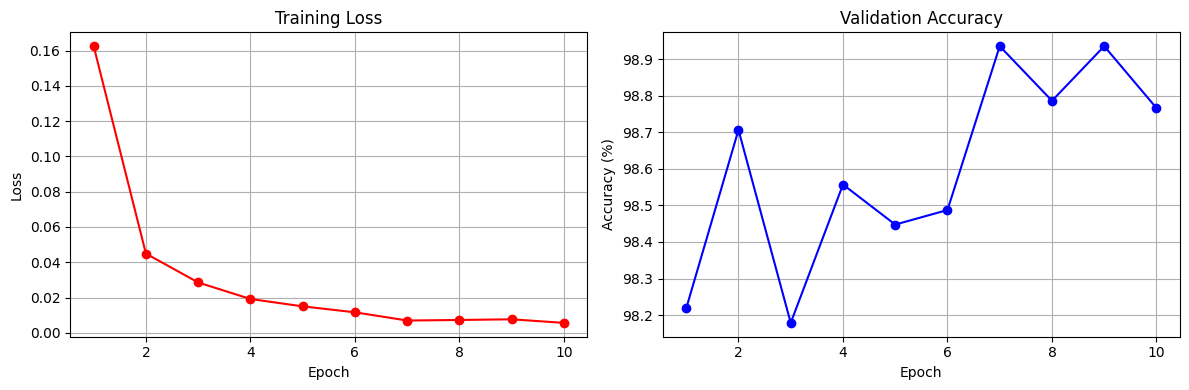

In [9]:
# --- PLOTTING IN NOTEBOOK ---
plt.figure(figsize=(12, 4))

# Loss Subplot
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Accuracy Subplot
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), val_accuracy, color='blue', marker='o')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.show()